# Image Thresholding Techniques

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from constants import *

max_pixel_val = 255  # means pure white

# Load the image in grayscale (thresholding needs single-channel input)
img_path = os.path.join(GENERAL_IMAGES_DIR, "handwritten_note.png")
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Check the path: {img_path}")

print("Image shape:", img.shape)

Image shape: (1089, 768)


### Adaptive Thresholding Parameters

**blockSize**: Size of the local neighborhood (odd number, e.g. 11, 15, 21) used to
compute the threshold for each pixel. Small size = threshold reacts to fine local
detail. Large size = threshold behaves more like global thresholding.

**C**: Constant subtracted from the local mean/weighted mean to get the final
threshold.

    threshold = local_mean(neighborhood) - C

- Higher C → stricter cutoff → less noise, but risk of losing faint/thin strokes
- Lower C → looser cutoff → preserves faint strokes, but risk of noisy background

**Trade-offs:**
| blockSize | Effect |
|---|---|
| Too small | Grainy/noisy output, sensitive to local variation |
| Too large | Loses fine detail, approaches global thresholding |

| C | Effect |
|---|---|
| Too high | Thin/broken strokes, missed faint ink |
| Too low | Speckled/noisy background |

In [13]:
# GLOBAL THRESHOLDING

# means one fixed threshold value applied to every pixel in the image.
# THRESH_BINARY: pixel > thresh -> 255 (white), else -> 0 (black)
_, global_thresh = cv2.threshold(img, 127, max_pixel_val, cv2.THRESH_BINARY)

In [28]:
# Adaptive mean thresholding: threshold is calculated per pixel as the mean
# of a local neighborhood (blockSize x blockSize), minus a constant C.

# Better for images with uneven/varying illumination across the page.
adaptive_mean = cv2.adaptiveThreshold(
    img, max_pixel_val,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize=20,
    C=28
)

In [19]:
# Adaptive Gaussian thresholding: same idea, but the local threshold is a
# weighted (Gaussian-weighted) sum of neighborhood pixels instead of a plain mean.
# Weighting favors pixels near the center of the window, giving smoother results.
adaptive_gaussian = cv2.adaptiveThreshold(
    img, max_pixel_val,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=15
)

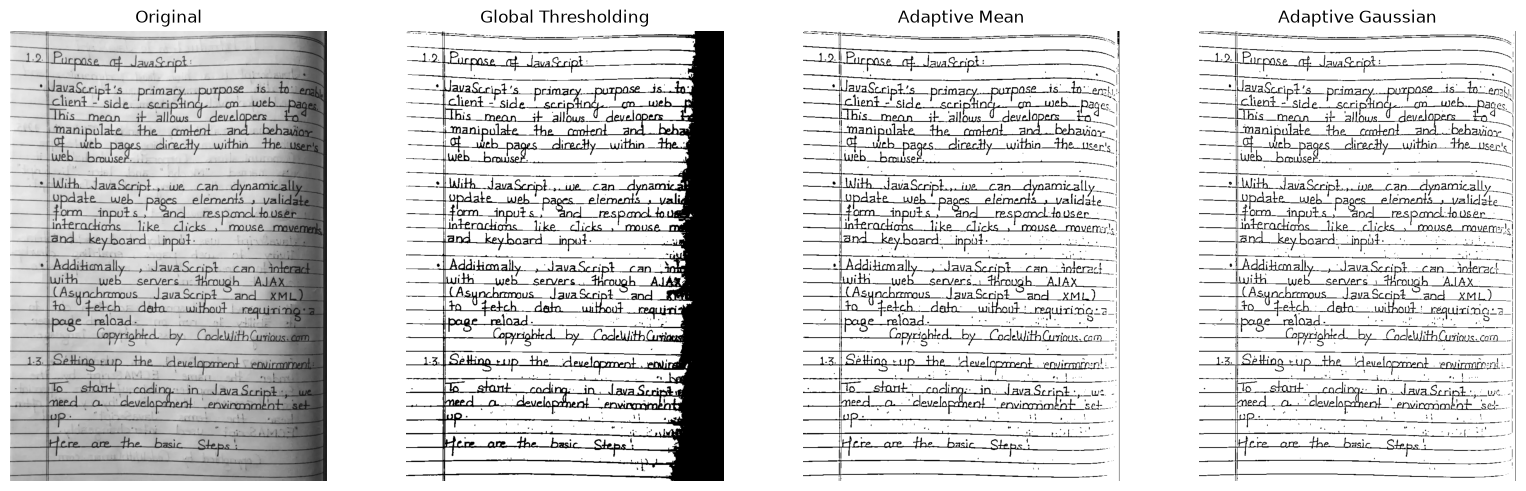

In [30]:
titles = ['Original', 'Global Thresholding', 'Adaptive Mean', 'Adaptive Gaussian']
images = [img, global_thresh, adaptive_mean, adaptive_gaussian]

plt.figure(figsize=(16, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

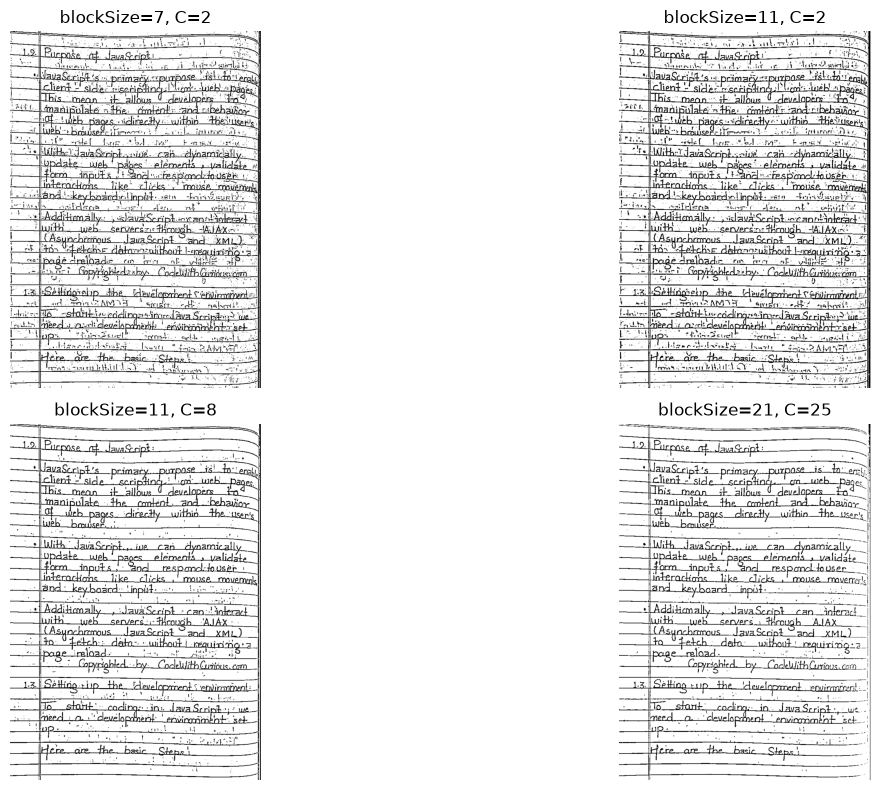

In [17]:
# Try a few combinations of blockSize and C to see their effect
params = [
    (7, 2),
    (11, 2),
    (11, 8),
    (21, 25),
]

plt.figure(figsize=(16, 8))
for i, (block_size, C) in enumerate(params):
    result = cv2.adaptiveThreshold(
        img, max_pixel_val,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=C
    )
    plt.subplot(2, 2, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(f"blockSize={block_size}, C={C}")
    plt.axis('off')

plt.tight_layout()
plt.show()